In [4]:
import json
import sys
from pathlib import Path

import numpy as np
import pandas as pd

project_root = Path.cwd().resolve()
if project_root.name == 'notebooks':
    project_root = project_root.parent
sys.path.append(str(project_root / 'src'))

from stable_baselines3 import DQN
from env import *
from agents.train_dqn import DQNConfig


In [5]:
df_test = pd.read_csv('../data/raw/binance_BTCUSDT_1h_2024.csv')

df_test.head()

,open,high,low,close,volume
0,42283.58,42554.57,42261.02,42475.23,1271.68108
1,42475.23,42775.00,42431.65,42613.56,1196.37856
2,42613.57,42638.41,42500.00,42581.10,685.21980
3,42581.09,42586.64,42230.08,42330.49,794.80391
4,42330.50,42399.99,42209.46,42399.99,715.41760


In [6]:
RUN_ID = "20260331-215051-54d8f8"
run_dir = project_root / 'experiments' / 'dqn-test-base' / f"{RUN_ID}"
config_path = run_dir / 'config.json'
model_path = run_dir / 'model'

config = DQNConfig(**json.loads(config_path.read_text()))
config

window_size = 10
env_test = MyTradingEnv(df_test, window_size=window_size)
env_test.clear_history()

model = DQN.load(str(model_path), env=env_test)

obs, _ = env_test.reset()
done = False

while not done:
    action, _ = model.predict(obs, deterministic=True)
    obs, reward, terminated, truncated, info = env_test.step(int(action))
    done = terminated or truncated




Wrapping the env with a `Monitor` wrapper
Wrapping the env in a DummyVecEnv.


In [7]:
test_steps = env_test.get_steps_df()
test_trades = env_test.get_trades_df()

test_steps.head()


,episode,step,df_index,action,reward,terminated,truncated,portfolio_value,cash,position,units,entry_price,position_value,holding_time,current_price,n_trades,last_exit_reason,unrealized_pnl
0,1,1,7280,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,72241.35,0,None,0.0
1,1,2,7281,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,72576.01,0,None,0.0
2,1,3,7282,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,72378.02,0,None,0.0
3,1,4,7283,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,71983.99,0,None,0.0
4,1,5,7284,0,0.0,False,False,1000.0,1000.0,0,0.0,0.0,0.0,0,71862.17,0,None,0.0


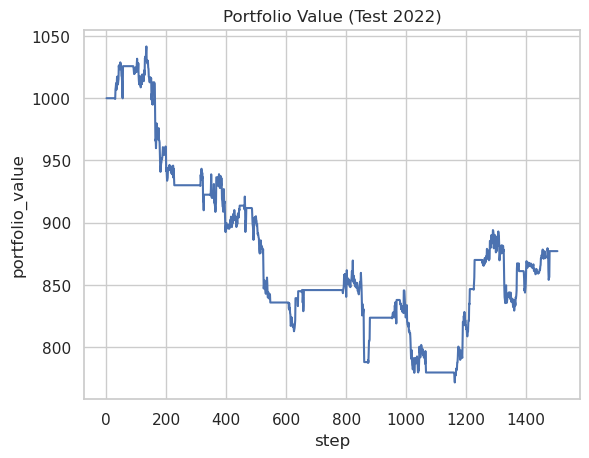

,entry_price,exit_price,pnl,units,holding_time,max_drawdown,exit_reason
0,71272.346000,69422.463885,25.855127,0.014029,26,0.000000,agent
1,68180.802545,69030.487995,-12.885771,0.015043,65,0.030055,agent
2,71060.491980,76850.406000,-82.620151,0.014251,66,0.080938,drawdown
3,87587.074555,88284.440160,-7.497988,0.010617,12,0.021533,agent
4,90148.413245,88764.390015,14.069946,0.010232,19,0.014903,agent


In [8]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.set_theme(style='whitegrid')

sns.lineplot(data=test_steps, x='step', y='portfolio_value')
plt.title('Portfolio Value (Test 2022)')
plt.show()

trades_df = test_trades
trades_df.head()
